# LOAN PREDICTION - COMPLETE MACHINE LEARNING PIPELINE
## Introduction
- In the modern financial landscape, banks and lending institutions receive thousands of loan applications every day. Manually evaluating each application is time-consuming, inconsistent, and prone to human bias. Machine Learning offers a powerful alternative it can learn patterns from historical data and predict outcomes with speed and consistency.
- This project tackles the classic Loan Approval Prediction problem, where we build a binary classification model that learns from applicant attributes such as income, credit score, employment status, and loan amount and predicts whether a loan application should be Approved (1) or Rejected (0).

## Problem Statement

- Given a set of applicant features, can we build a machine learning model that accurately predicts whether a loan will be approved?

## Importing Libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay) 

# LOAD DATASET

In [29]:
df= pd.read_csv('loan_prediction_dataset.csv')
df.head()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0


In [30]:
# Checking MISSING DATA
df.isnull().sum()

Age                  0
Income               0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Employment_Status    0
Loan_Approved        0
dtype: int64

- no missing values

# FEATURE ENGINEERING & ENCODING

In [31]:
le= LabelEncoder()
df['Employment_Status_Encoded']=le.fit_transform(df['Employment_Status'])
print(f"   Employment classes : {list(le.classes_)}")
print(f"   Mapped to integers : {list(range(len(le.classes_)))}")

   Employment classes : ['Employed', 'Self-Employed', 'Unemployed']
   Mapped to integers : [0, 1, 2]


# VISUALIZATIONS

## Plot 1: Target Class Distribution

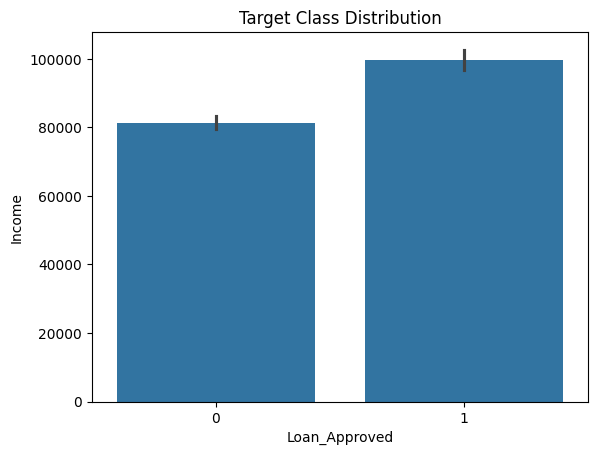

In [32]:
sns.barplot(data=df,x='Loan_Approved', y='Income')
plt.title("Target Class Distribution")
plt.show()

# Plot 2: Loan Amount Distribution

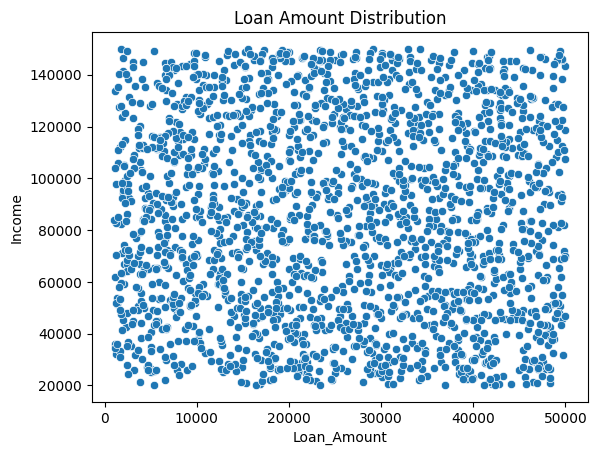

In [33]:
sns.scatterplot(data=df,x='Loan_Amount', y='Income')
plt.title('Loan Amount Distribution')
plt.show()

# Plot 3: Income Distribution by Approval 

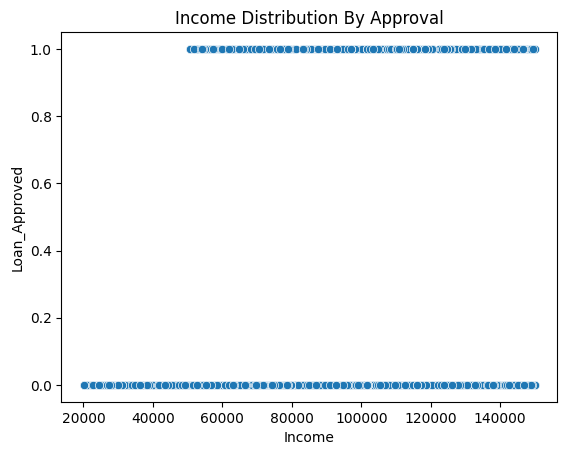

In [34]:
sns.scatterplot(data=df,x='Income', y='Loan_Approved')
plt.title("Income Distribution By Approval")
plt.show()

# Plot 4: Education / Employment Status

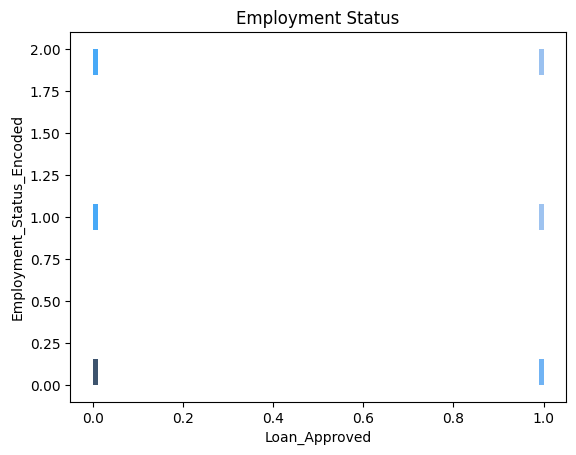

In [35]:
sns.histplot(data=df,x='Loan_Approved', y='Employment_Status_Encoded')
plt.title("Employment Status")
plt.show()

# PREPARE FEATURES & SPLIT DATA

In [36]:
FEATURES = ['Age', 'Income', 'Credit_Score', 'Loan_Amount',
            'Loan_Term', 'Employment_Status_Encoded']
TARGET   = 'Loan_Approved'
 
X = df[FEATURES]
y = df[TARGET]
print(f"   Feature set   : {FEATURES}")
print(f"   Target        : {TARGET}")
print(f"   Class balance : {dict(y.value_counts())}")

   Feature set   : ['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term', 'Employment_Status_Encoded']
   Target        : Loan_Approved
   Class balance : {0: np.int64(1658), 1: np.int64(342)}


In [37]:
# Scale features for Logistic Regression
scaler= StandardScaler()
X_scaled= scaler.fit_transform(X)

In [38]:
# 80/20 train-test split, stratified to preserve class ratio
X_train,X_test,y_train,y_test= train_test_split(X_scaled,y,test_size=0.20,random_state=42, stratify=y)
print(f"   Train samples : {len(X_train)} | Test samples : {len(X_test)}")

   Train samples : 1600 | Test samples : 400


# TRAIN MODELS

### Model A: Logistic Regression

In [40]:
lr_model= LogisticRegression(max_iter=500, random_state=42, class_weight='balanced')
lr_model.fit(X_train,y_train)
lr_pred= lr_model.predict(X_test)
lr_acc= accuracy_score(y_test,lr_pred)
lr_cm= confusion_matrix(y_test,lr_pred)
print(f"\n   ▶ Logistic Regression:")
print(f"     Accuracy : {lr_acc * 100:.2f}%")
print(f"     Confusion Matrix:\n{lr_cm}")
print(f"\n     Classification Report:\n"
      f"{classification_report(y_test, lr_pred, target_names=['Rejected','Approved'])}")


   ▶ Logistic Regression:
     Accuracy : 88.00%
     Confusion Matrix:
[[287  45]
 [  3  65]]

     Classification Report:
              precision    recall  f1-score   support

    Rejected       0.99      0.86      0.92       332
    Approved       0.59      0.96      0.73        68

    accuracy                           0.88       400
   macro avg       0.79      0.91      0.83       400
weighted avg       0.92      0.88      0.89       400



#### class_weight='balanced'
- This is the most important parameter in the entire model for this dataset.
- The problem it solves: Our dataset has a severe class imbalance:

- 1,658 Rejected (83%)
- 342 Approved (17%)

- If you train without this parameter, the model learns a shortcut: "just predict Rejected every time and I'll be right 83% of the time." That's a useless model — it will never approve any loan.
- What 'balanced' does: It automatically calculates a penalty weight for each class:
- weight for class = total_samples / (n_classes × samples_in_that_class)

- Weight for Approved  = 2000 / (2 × 342)  ≈ 2.92   ← heavily penalized
- Weight for Rejected  = 2000 / (2 × 1658) ≈ 0.60   ← lightly penalized

- This forces the model to treat one missed approval as nearly 3× more costly than one missed rejection, compelling it to actually learn the minority class pattern instead of ignoring it.

### Model B: Decision Tree 

In [43]:
dt_model= DecisionTreeClassifier(max_depth=5, random_state=42,class_weight='balanced')
dt_model.fit(X_train,y_train)
dt_pred= dt_model.predict(X_test)
dt_acc= accuracy_score(y_test,dt_pred)
dt_cm= confusion_matrix(y_test,dt_pred)

print(f"\n   ▶ Decision Tree (max_depth=5):")
print(f"     Accuracy : {dt_acc * 100:.2f}%")
print(f"     Confusion Matrix:\n{dt_cm}")
print(f"\n     Classification Report:\n"
      f"{classification_report(y_test, dt_pred, target_names=['Rejected','Approved'])}")


   ▶ Decision Tree (max_depth=5):
     Accuracy : 100.00%
     Confusion Matrix:
[[332   0]
 [  0  68]]

     Classification Report:
              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00       332
    Approved       1.00      1.00      1.00        68

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



# FINAL SUMMARY

In [46]:
best_model = "Logistic Regression" if lr_acc >= dt_acc else "Decision Tree"
best_acc   = max(lr_acc, dt_acc) * 100
print(f"  ✅ Logistic Regression Accuracy : {lr_acc*100:.2f}%")
print(f"  ✅ Decision Tree Accuracy        : {dt_acc*100:.2f}%")
print(f"  🏆 Best Model                   : {best_model} ({best_acc:.2f}%)")

  ✅ Logistic Regression Accuracy : 88.00%
  ✅ Decision Tree Accuracy        : 100.00%
  🏆 Best Model                   : Decision Tree (100.00%)
